In [1]:
import matplotlib.pyplot as plt
import numpy as np


In [5]:

def make_class(mean, cov, n=20, seed=0):
    rng = np.random.default_rng(seed)
    return rng.multivariate_normal(mean, cov, n)

def decision_boundary(x):
    return 0.5 * np.sin(1.2 * x) + 0.1 * x

def plot_panel(X1, X2, title, boundary_shift=0):
    x = np.linspace(-3, 3, 300)
    y = decision_boundary(x) + boundary_shift

    plt.scatter(X1[:,0], X1[:,1], c="#0b4f6c", label="Class 1")
    plt.scatter(X2[:,0], X2[:,1], c="#c1121f", marker="s", label="Class 2")
    plt.plot(x, y, color="#7a1f3d", linewidth=2)

    plt.xticks([])   # remove x-axis numbers
    plt.yticks([])  # remove y-axis numbers

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title(title)
    plt.axis("equal")
    plt.tight_layout()

In [6]:
X1 = make_class(mean=[0, 1], cov=[[0.2, 0], [0, 0.2]])
X2 = make_class(mean=[0, -1], cov=[[0.2, 0], [0, 0.2]])

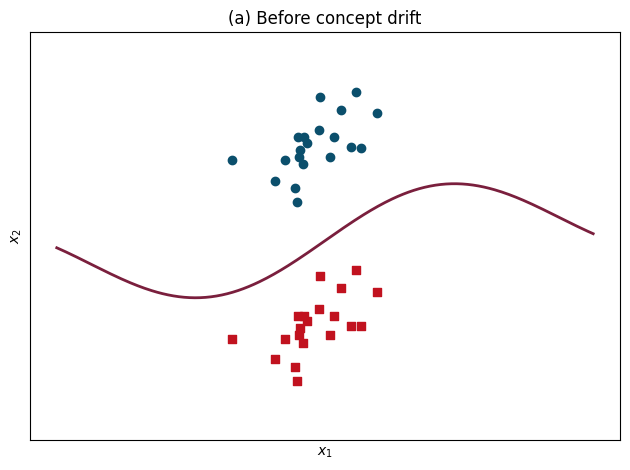

In [7]:
plot_panel(X1, X2, "(a) Before concept drift")

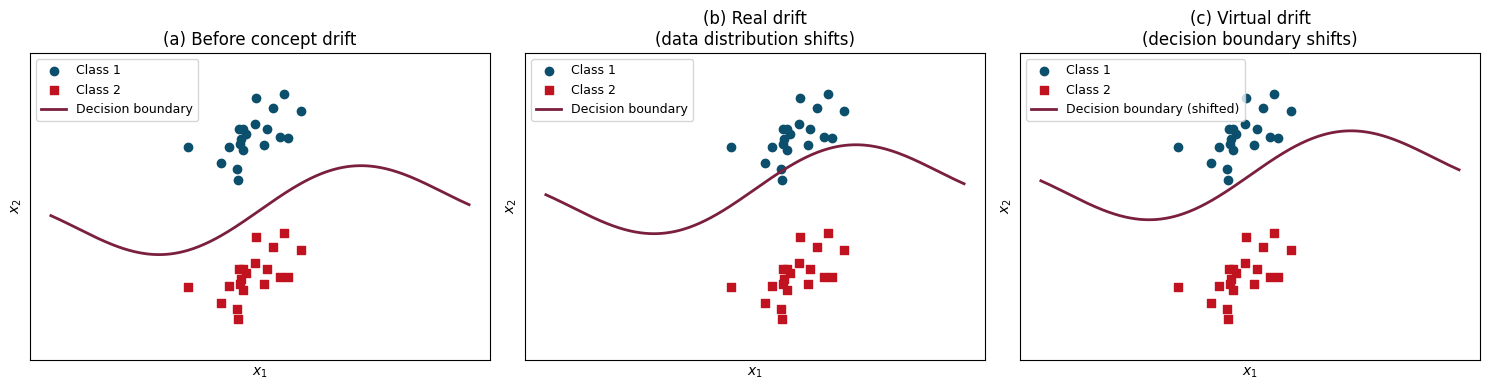

In [8]:
X1_drift = X1 + np.array([0.7, -0.3])
X2_drift = X2 + np.array([0.7, -0.3])

# Create 1x3 subplot layout
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel (a): Before drift
ax = axes[0]
x = np.linspace(-3, 3, 300)
y = decision_boundary(x)

ax.scatter(X1[:,0], X1[:,1], c="#0b4f6c", label="Class 1")
ax.scatter(X2[:,0], X2[:,1], c="#c1121f", marker="s", label="Class 2")
ax.plot(x, y, color="#7a1f3d", linewidth=2, label="Decision boundary")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("(a) Before concept drift")
ax.axis("equal")
ax.legend(loc="upper left", fontsize=9)

# Panel (b): Real drift (data shifts)
ax = axes[1]
x = np.linspace(-3, 3, 300)
y = decision_boundary(x)

ax.scatter(X1_drift[:,0], X1_drift[:,1], c="#0b4f6c", label="Class 1")
ax.scatter(X2_drift[:,0], X2_drift[:,1], c="#c1121f", marker="s", label="Class 2")
ax.plot(x, y, color="#7a1f3d", linewidth=2, label="Decision boundary")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("(b) Real drift\n(data distribution shifts)")
ax.axis("equal")
ax.legend(loc="upper left", fontsize=9)

# Panel (c): Virtual drift (boundary shifts, data stays same)
ax = axes[2]
x = np.linspace(-3, 3, 300)
y = decision_boundary(x) + 0.5  # boundary shifts up

ax.scatter(X1[:,0], X1[:,1], c="#0b4f6c", label="Class 1")
ax.scatter(X2[:,0], X2[:,1], c="#c1121f", marker="s", label="Class 2")
ax.plot(x, y, color="#7a1f3d", linewidth=2, label="Decision boundary (shifted)")
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("(c) Virtual drift\n(decision boundary shifts)")
ax.axis("equal")
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.show()

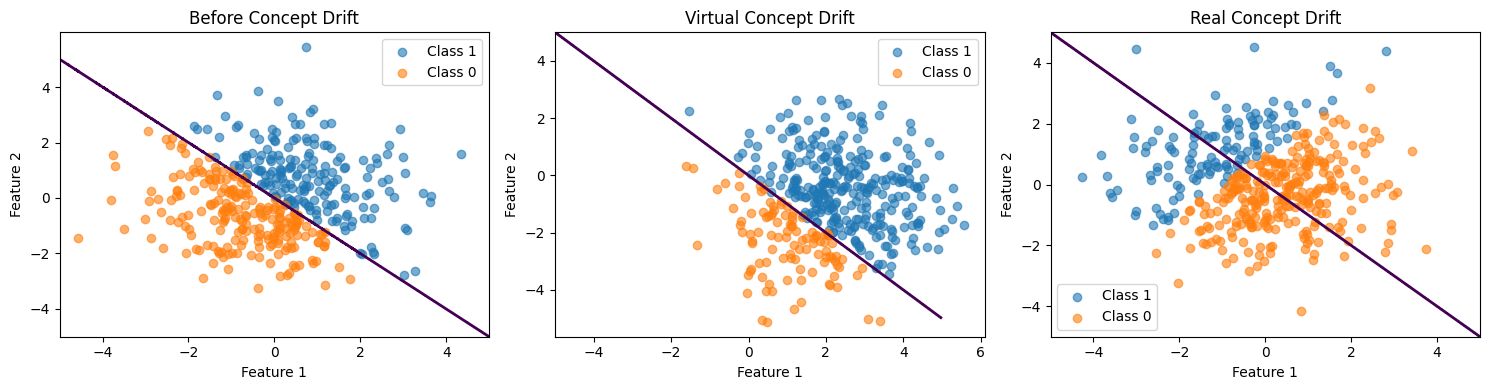

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

# Number of samples
n = 400

# =========================
# Linear decision functions
# =========================
def decision_boundary_before(X):
    # Linear boundary: x1 + x2 - 0 = 0
    return X[:, 0] + X[:, 1]

def decision_boundary_real(X):
    # Changed linear boundary: -x1 + x2 - 1 = 0
    return -X[:, 0] + X[:, 1] - 1


# =========================
# Data generation
# =========================

# --- Before Concept Drift ---
X_before = np.random.multivariate_normal(
    mean=[0, 0], cov=[[2, 0], [0, 2]], size=n
)
y_before = decision_boundary_before(X_before) > 0

# --- Virtual Concept Drift ---
# Input distribution changes, boundary unchanged
X_virtual = np.random.multivariate_normal(
    mean=[2, -1], cov=[[2, 0], [0, 2]], size=n
)
y_virtual = decision_boundary_before(X_virtual) > 0

# --- Real Concept Drift ---
# Boundary changes
X_real = np.random.multivariate_normal(
    mean=[0, 0], cov=[[2, 0], [0, 2]], size=n
)
y_real = decision_boundary_real(X_real) > 0


# =========================
# Mesh for plotting boundaries
# =========================
xx, yy = np.meshgrid(
    np.linspace(-5, 5, 400),
    np.linspace(-5, 5, 400)
)
grid = np.c_[xx.ravel(), yy.ravel()]

Z_before = decision_boundary_before(grid).reshape(xx.shape)
Z_real = decision_boundary_real(grid).reshape(xx.shape)


# =========================
# Plotting
# =========================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Before Concept Drift ---
axes[0].scatter(X_before[y_before, 0], X_before[y_before, 1], alpha=0.6, label="Class 1")
axes[0].scatter(X_before[~y_before, 0], X_before[~y_before, 1], alpha=0.6, label="Class 0")
axes[0].contour(xx, yy, Z_before, levels=[0], linewidths=2)
axes[0].set_title("Before Concept Drift")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()

# --- Virtual Concept Drift ---
axes[1].scatter(X_virtual[y_virtual, 0], X_virtual[y_virtual, 1], alpha=0.6, label="Class 1")
axes[1].scatter(X_virtual[~y_virtual, 0], X_virtual[~y_virtual, 1], alpha=0.6, label="Class 0")
axes[1].contour(xx, yy, Z_before, levels=[0], linewidths=2)
axes[1].set_title("Virtual Concept Drift")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()

# --- Real Concept Drift ---
axes[2].scatter(X_real[y_real, 0], X_real[y_real, 1], alpha=0.6, label="Class 1")
axes[2].scatter(X_real[~y_real, 0], X_real[~y_real, 1], alpha=0.6, label="Class 0")
axes[2].contour(xx, yy, Z_before, levels=[0], linewidths=2)
axes[2].set_title("Real Concept Drift")
axes[2].set_xlabel("Feature 1")
axes[2].set_ylabel("Feature 2")
axes[2].legend()

plt.tight_layout()
plt.show()
